In [1]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

import sys
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import scipy
from itertools import combinations

In [41]:
for i in range(50):
    np.random.seed(i)
    
    G = grn().add_structure(
    n=256,
    k=1,
    alpha=1e-99,
    beta=0.99,       # 1 - 1/r
    gamma=0.01,      # 1/r
    kappa=10,        # --w
    delta_in=100,
    delta_out=100,
    )
    G.simulate_rna(
    s=1e-4,
    dt=1e-2,
    tmax=20000,
    burnin=5000,
    tol=1e-3,
    save=True,
    )
    B = G.beta 
    x = G.rna.flatten()
    l = G.l.flatten()
    a = G.alpha.flatten()
    
    # jacobian
    sig = scipy.special.expit(a + B.T@x.reshape(-1,1))
    #sig = (l*x)
    A = B.T * (sig * (1 - sig)) - np.diag(l)
    evals, evecs = np.linalg.eig(A)
       
    # result
    stable = all(evals.real < 0)
    print(i, 'has converged -', G.converged, 'and is stable -', stable)
    
    

0 has converged - False and is stable - False
1 has converged - False and is stable - False
2 has converged - False and is stable - True
3 has converged - False and is stable - False
4 has converged - False and is stable - False
5 has converged - True and is stable - True
6 has converged - False and is stable - False
7 has converged - True and is stable - True
8 has converged - False and is stable - False
9 has converged - False and is stable - True
10 has converged - True and is stable - True
11 has converged - True and is stable - True
12 has converged - True and is stable - True


KeyboardInterrupt: 

In [4]:
sys.path.insert(0, "src")

from grn import grn

np.random.seed(5)


In [5]:
#manually adjust GRN hyperparameters in an attempt to build GRN with more non-additive effects
G = grn().add_structure(
    n=256,
    k=1,
    alpha=1e-99,
    beta=0.99,       # 1 - 1/r
    gamma=0.01,      # 1/r
    kappa=10,        # --w
    delta_in=100,
    delta_out=100,
)

In [6]:
G.simulate_rna(
    s=1e-4,
    dt=1e-2,
    tmax=20000,
    burnin=5000,
    tol=1e-3,
    save=True,
)


array([[4.84649231e-10, 4.18872025e-01, 3.77322668e-03, 1.69880546e-10,
        1.06239300e+00, 3.58549281e-07, 5.00508449e-07, 1.01727610e+00,
        9.22185642e-05, 1.12122699e+00, 2.52883912e-02, 1.08584806e+00,
        1.25280245e-09, 1.20867685e+00, 1.53776463e+00, 1.08056495e-08,
        1.55010171e-04, 1.83459186e-06, 1.09137161e+00, 1.06043472e-09,
        1.08336101e+00, 8.00775265e-03, 1.21524535e+00, 2.25520557e-09,
        9.16532224e-03, 1.34900708e+00, 1.06786693e+00, 8.67781628e-01,
        8.78636767e-02, 1.01295853e+00, 8.87810232e-10, 1.04249830e+00,
        1.02088890e+00, 1.16010403e+00, 3.11985535e-03, 9.27389566e-01,
        1.93303618e-09, 9.72905997e-01, 1.06724803e+00, 1.32670786e-08,
        1.97531781e-03, 1.81200185e-01, 3.82578343e-04, 1.23273126e-06,
        1.06109423e+00, 1.41638243e+00, 1.19667148e+00, 9.15270357e-02,
        1.13071151e+00, 1.03317256e+00, 3.75856888e-07, 1.01290271e+00,
        1.08133226e+00, 1.20993819e+00, 1.05294511e+00, 1.630200

In [45]:
np.save('../256g_smallV2_rna', G.rna)

In [11]:
wt_expression = np.asarray(G.rna).flatten()

wt_df = pd.DataFrame(
    [wt_expression],
    index=["WT"],
    columns=[f"gene_{i}" for i in range(G.n)],
)

wt_df.to_csv("wt_expression.csv")

print("Converged:", G.converged)
print("Expression shape:", wt_expression.shape)
display(wt_df)

Converged: True
Expression shape: (256,)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_246,gene_247,gene_248,gene_249,gene_250,gene_251,gene_252,gene_253,gene_254,gene_255
WT,4.846492e-10,0.418872,0.003773,1.698805e-10,1.062393,3.585493e-07,5.005084e-07,1.017276,0.000092,1.121227,...,0.001908,0.095047,0.00083,0.09104,0.1389,0.861876,0.868824,0.060821,0.122791,0.453823


In [12]:
B = G.beta 
x = G.rna.flatten()
l = G.l.flatten()
a = G.alpha.flatten()
    
# jacobian
sig = scipy.special.expit(a + B.T@x.reshape(-1,1))
#sig = (l*x)
A = B.T * (sig * (1 - sig)) - np.diag(l)
evals, evecs = np.linalg.eig(A)
       
# result
stable = all(evals.real < 0)
print(stable)

True


In [13]:
ko_expression = np.zeros((G.n, G.n))
ko_logfc = np.zeros((G.n, G.n))

for gene in tqdm(range(G.n), desc="Simulating single-gene KOs"):
    
    result = G.ko_nodes(
        genes=[gene],
        stats=("new_rna", 'logfc'),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )
    
    ko_expression[gene, :] = result["new_rna"].flatten()
    ko_logfc[gene, :] = result["logfc"].flatten()

# Rows = perturbations
# Columns = measured genes
ko_df = pd.DataFrame(
    ko_expression,
    index=[f"KO_{i}" for i in range(G.n)],
    columns=[f"gene_{i}" for i in range(G.n)],
)

fc_ko_df = pd.DataFrame(
    ko_logfc,
    index=[f"KO_{i}" for i in range(G.n)],
    columns=[f"gene_{i}" for i in range(G.n)],
)



# Save KO expression only
ko_df.to_csv("single_KO_expression.csv")

# Also save one convenient combined WT + KO matrix
expression_df = pd.concat([wt_df, ko_df])

expression_df.to_csv("WT_and_single_KO_expression.csv")

print("KO matrix shape:", ko_df.shape)
print("Combined matrix shape:", expression_df.shape)

display(expression_df.head())

Simulating single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

KO matrix shape: (256, 256)
Combined matrix shape: (257, 256)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_246,gene_247,gene_248,gene_249,gene_250,gene_251,gene_252,gene_253,gene_254,gene_255
WT,4.846492e-10,0.418872,0.003773,1.698805e-10,1.062393,3.585493e-07,5.005084e-07,1.017276,0.000092,1.121227,...,0.001908,0.095047,0.000830,0.091040,0.138900,0.861876,0.868824,0.060821,0.122791,0.453823
KO_0,1.060583e-09,0.419042,0.003773,1.064903e-10,1.062362,3.549742e-07,5.104273e-07,1.017280,0.000092,1.121247,...,0.001909,0.095032,0.000829,0.091044,0.138886,0.861874,0.868848,0.060821,0.122800,0.453819
KO_1,1.085226e-09,1.100006,0.001693,1.666864e-10,1.062154,8.956330e-07,8.988239e-09,1.017294,0.000668,1.121777,...,0.001932,0.114087,0.002034,0.089167,0.134575,0.861735,0.682201,0.095818,0.122394,0.453815
KO_2,7.095636e-10,0.423892,0.003902,3.220778e-10,1.062359,3.449963e-07,5.301149e-07,1.017288,0.000091,1.121264,...,0.001908,0.095690,0.000814,0.091026,0.138962,0.861894,0.867836,0.060497,0.123397,0.453807
KO_3,1.827475e-10,0.419031,0.003774,1.534935e-10,1.062384,3.650663e-07,4.983737e-07,1.017294,0.000092,1.121236,...,0.001908,0.095029,0.000830,0.091039,0.138891,0.861913,0.868811,0.060819,0.122788,0.453826


In [49]:
fc_ko_df.head()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_246,gene_247,gene_248,gene_249,gene_250,gene_251,gene_252,gene_253,gene_254,gene_255
KO_0,1.129844,0.000586,0.000036,-0.673798,-0.000042,-0.014457,0.028311,0.000006,-0.003650,0.000026,...,0.000801,-0.000225,-0.001634,0.000059,-0.000144,-0.000002,0.000039,-0.000004,0.000114,-0.000013
KO_1,1.162983,1.392930,-1.155984,-0.027385,-0.000324,1.320736,-5.799212,0.000025,2.857051,0.000708,...,0.018130,0.263419,1.293121,-0.029994,-0.045639,-0.000235,-0.348867,0.655739,-0.004669,-0.000025
KO_2,0.549991,0.017188,0.048365,0.922889,-0.000046,-0.055590,0.082911,0.000017,-0.025961,0.000048,...,0.000697,0.009730,-0.027774,-0.000222,0.000647,0.000031,-0.001642,-0.007691,0.007105,-0.000051
KO_3,-1.407090,0.000548,0.000209,-0.146343,-0.000012,0.025987,-0.006167,0.000026,-0.003730,0.000012,...,0.000287,-0.000273,-0.000506,-0.000030,-0.000087,0.000062,-0.000021,-0.000050,-0.000032,0.000009
KO_4,22.910887,1.541348,6.190676,7.638922,-0.242112,15.493733,13.315159,-0.130048,12.537960,-2.716378,...,5.348490,0.930324,3.383192,-0.034654,0.140656,-0.057879,-0.021262,-1.115226,1.034360,0.000016


In [53]:
pairs = np.array(
    list(combinations(range(G.n), 2)),
    dtype=np.int32
)

print("Number of genes:", G.n)
print("Number of double perturbations:", len(pairs))
# For n=200: 19,900

Number of genes: 256
Number of double perturbations: 32640


In [27]:
indices = np.random.choice(len(pairs), size=32640, replace=False)

# Subset the array using the chosen indices
subset_pairs = pairs[indices]

In [28]:
subset_pairs

array([[ 61, 241],
       [ 35, 218],
       [ 38,  91],
       ...,
       [ 55, 152],
       [ 67, 136],
       [ 94, 115]], shape=(32640, 2), dtype=int32)

In [69]:
n_jobs = 4   # increase if you have enough CPU/RAM

def run_double_ko(pair):
    a, b = pair

    result = G.ko_nodes(
        genes=[a, b],
        stats=("logfc",),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )

    return result["logfc"].flatten()


double_results = Parallel(
    n_jobs=n_jobs,
    pre_dispatch="n_jobs",
    prefer="processes",
    verbose=10,
)(
    delayed(run_double_ko)(pair)
    for pair in subset_pairs
)

double_logfc = np.asarray(double_results, dtype=np.float32)

print("pairs:", subset_pairs.shape)
print("double_logfc:", double_logfc.shape)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:    1.3s
[Parallel(n_jobs=4)]: Done   4 tasks      | elapsed:    1.6s
[Parallel(n_jobs=4)]: Done   9 tasks      | elapsed:    2.3s
[Parallel(n_jobs=4)]: Done  14 tasks      | elapsed:    3.0s
[Parallel(n_jobs=4)]: Done  21 tasks      | elapsed:    3.8s
[Parallel(n_jobs=4)]: Done  28 tasks      | elapsed:    4.9s
[Parallel(n_jobs=4)]: Done  37 tasks      | elapsed:    6.1s
[Parallel(n_jobs=4)]: Done  46 tasks      | elapsed:    7.3s
[Parallel(n_jobs=4)]: Done  57 tasks      | elapsed:    8.7s
[Parallel(n_jobs=4)]: Done  68 tasks      | elapsed:    9.8s
[Parallel(n_jobs=4)]: Done  81 tasks      | elapsed:   11.3s
[Parallel(n_jobs=4)]: Done  94 tasks      | elapsed:   13.0s
[Parallel(n_jobs=4)]: Done 109 tasks      | elapsed:   14.9s
[Parallel(n_jobs=4)]: Done 124 tasks      | elapsed:   17.4s
[Parallel(n_jobs=4)]: Done 141 tasks      | elapsed:   19.8s
[Parallel(

pairs: (32640, 2)
double_logfc: (32640, 256)


[Parallel(n_jobs=4)]: Done 32640 out of 32640 | elapsed: 71.2min finished


In [45]:
np.savez_compressed(
    "../256small_GRN_all_double_KO.npz",
    pairs=pairs,
    double_logfc=double_logfc,
)

print("Saved 256small_GRN_all_double_KO.npz")

Saved 256small_GRN_all_double_KO.npz


In [19]:
subset_pairs = pairs

In [29]:
single_logfc = np.asarray(ko_logfc)

single_a = single_logfc[subset_pairs[:, 0], :]
single_b = single_logfc[subset_pairs[:, 1], :]

expected_additive = single_a + single_b

interaction_residuals = double_logfc - expected_additive

print("double KO:", double_logfc.shape)
print("additive expectation:", expected_additive.shape)
print("interaction residuals:", interaction_residuals.shape)

double KO: (32640, 256)
additive expectation: (32640, 256)
interaction residuals: (32640, 256)


In [30]:
errors = interaction_residuals.ravel()

# Just in case a simulation produced zero expression and therefore
# an infinite logFC:
errors = errors[np.isfinite(errors)]

print("Number of residuals:", len(errors))
print("Mean:", errors.mean())
print("SD:", errors.std())

print("Quantiles:")
print(
    np.quantile(
        errors,
        [0, 0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999, 1]
    )
)

Number of residuals: 8355840
Mean: 3.303837011750411
SD: 8.450171857206527
Quantiles:
[-24.00592586 -12.3549908   -8.88966865  -5.36343775   0.1667229
  22.10539602  30.2037552   35.52439616  47.51448128]


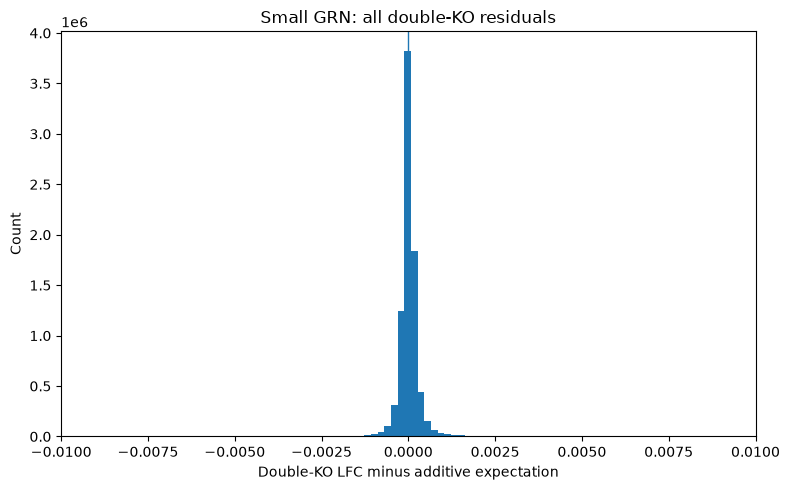

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

plt.xlim(-0.01, 0.01)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title("Small GRN: all double-KO residuals")

plt.tight_layout()
plt.show()

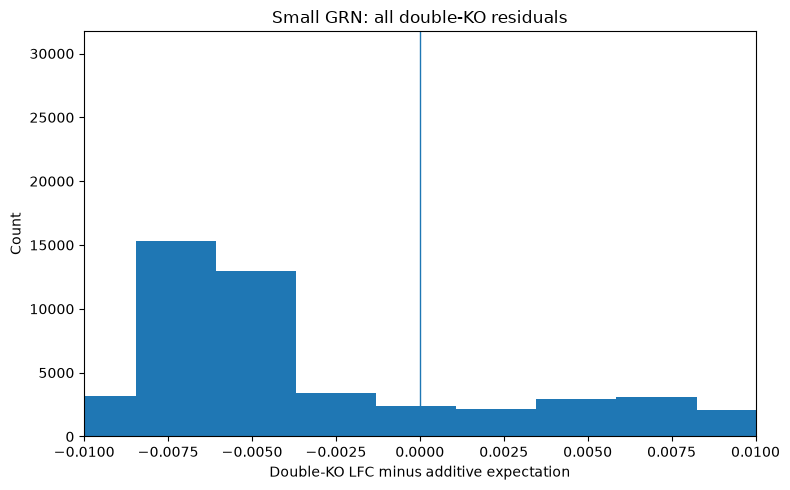

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

plt.xlim(-0.01, 0.01)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title("Small GRN: all double-KO residuals")

plt.tight_layout()
plt.show()

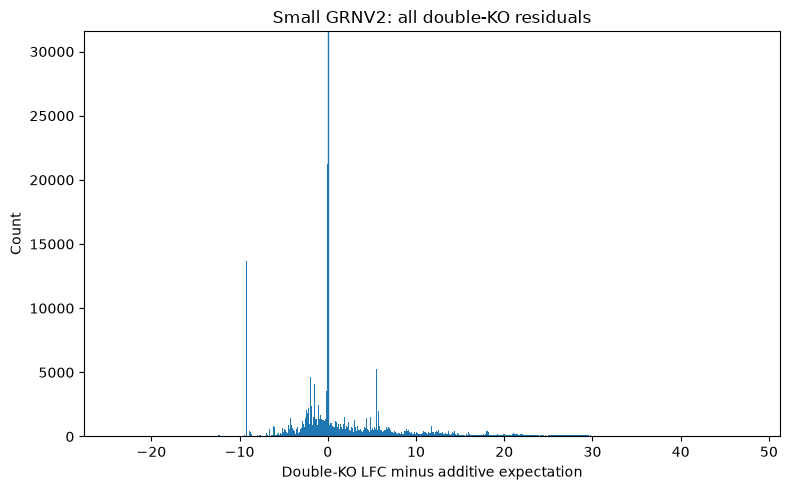

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

#plt.xlim(-0.01, 0.01)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title("Small GRNV2: all double-KO residuals")

plt.tight_layout()
plt.show()

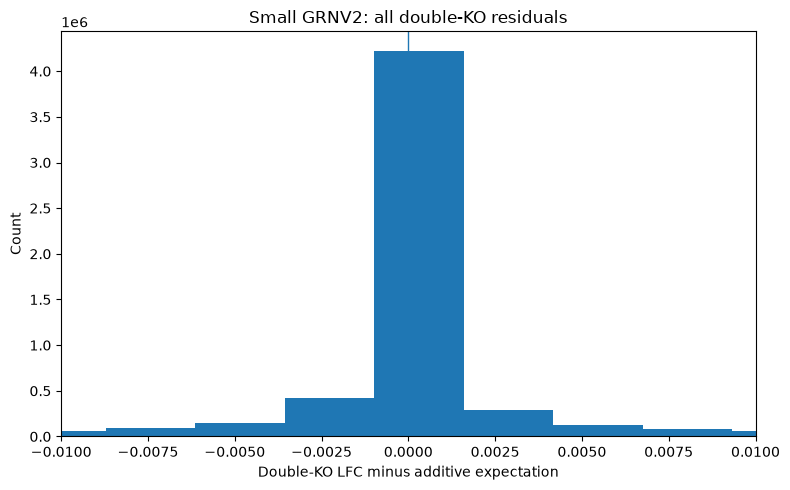

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

plt.xlim(-0.01, 0.01)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title("Small GRNV2: all double-KO residuals")

plt.tight_layout()
plt.show()

In [50]:
def run_double_ko(pair):
    a, b = pair

    result = G.ko_nodes(
        genes=[a, b],
        stats=("new_rna", "logfc"),
        s=1e-4,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )

    return (
        np.asarray(result["new_rna"]).flatten(),
        np.asarray(result["logfc"]).flatten(),
    )


results = Parallel(
    n_jobs=4,
    pre_dispatch="n_jobs",
    prefer="processes",
    verbose=10,
)(
    delayed(run_double_ko)(pair)
    for pair in pairs
)

double_expression = np.asarray(
    [r[0] for r in results],
    dtype=np.float32
)

double_logfc = np.asarray(
    [r[1] for r in results],
    dtype=np.float32
)

print("double_expression:", double_expression.shape)
print("double_logfc:", double_logfc.shape)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done   4 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Done   9 tasks      | elapsed:    1.8s
[Parallel(n_jobs=4)]: Done  14 tasks      | elapsed:    2.1s
[Parallel(n_jobs=4)]: Done  21 tasks      | elapsed:    2.6s
[Parallel(n_jobs=4)]: Done  28 tasks      | elapsed:    3.0s
[Parallel(n_jobs=4)]: Done  37 tasks      | elapsed:    3.5s
[Parallel(n_jobs=4)]: Done  46 tasks      | elapsed:    4.0s
[Parallel(n_jobs=4)]: Done  57 tasks      | elapsed:    4.7s
[Parallel(n_jobs=4)]: Done  68 tasks      | elapsed:    5.5s
[Parallel(n_jobs=4)]: Done  81 tasks      | elapsed:    6.3s
[Parallel(n_jobs=4)]: Done  94 tasks      | elapsed:    7.1s
[Parallel(n_jobs=4)]: Done 109 tasks      | elapsed:    8.1s
[Parallel(n_jobs=4)]: Done 124 tasks      | elapsed:    8.9s
[Parallel(n_jobs=4)]: Done 141 tasks      | elapsed:   10.1s
[Parallel(

double_expression: (32640, 256)
double_logfc: (32640, 256)


[Parallel(n_jobs=4)]: Done 32640 out of 32640 | elapsed: 35.4min finished


In [52]:
double_expression

array([[0.22902459, 0.26820517, 0.12691699, ..., 0.23021702, 0.07571758,
        0.03744688],
       [0.19038707, 0.17882472, 0.15229994, ..., 0.27422905, 0.06395153,
        0.02563071],
       [0.18919596, 0.24381807, 0.10982393, ..., 0.24741939, 0.07401819,
        0.03559477],
       ...,
       [0.18932737, 0.26252168, 0.0791078 , ..., 0.28473815, 0.07106488,
        0.03248731],
       [0.18931797, 0.26252457, 0.07910712, ..., 0.28471857, 0.07106034,
        0.03248477],
       [0.18929853, 0.26252174, 0.0791178 , ..., 0.2847334 , 0.07106682,
        0.03248161]], shape=(32640, 256), dtype=float32)

In [53]:
np.savez_compressed(
    "../256small_GRN_all_double_KO_exp.npz",
    pairs=pairs,
    double_expr=double_expression,
)

print("Saved 256small_GRN_all_double_KO_exp.npz")

Saved 256small_GRN_all_double_KO_exp.npz


In [2]:
with np.load("../256small_GRN_all_double_KO_exp.npz") as data:
    pairs = data["pairs"]
    double_expression = data["double_expr"]

In [7]:
double_expression 

array([[0.22902459, 0.26820517, 0.12691699, ..., 0.23021702, 0.07571758,
        0.03744688],
       [0.19038707, 0.17882472, 0.15229994, ..., 0.27422905, 0.06395153,
        0.02563071],
       [0.18919596, 0.24381807, 0.10982393, ..., 0.24741939, 0.07401819,
        0.03559477],
       ...,
       [0.18932737, 0.26252168, 0.0791078 , ..., 0.28473815, 0.07106488,
        0.03248731],
       [0.18931797, 0.26252457, 0.07910712, ..., 0.28471857, 0.07106034,
        0.03248477],
       [0.18929853, 0.26252174, 0.0791178 , ..., 0.2847334 , 0.07106682,
        0.03248161]], shape=(32640, 256), dtype=float32)

In [8]:
pairs

array([[  0,   1],
       [  0,   2],
       [  0,   3],
       ...,
       [253, 254],
       [253, 255],
       [254, 255]], shape=(32640, 2), dtype=int32)

In [10]:
G.rna.shape

(256,)

In [21]:
double_logfc = np.log2(double_expression) - np.log2(G.rna)

In [17]:
double_expression

array([[0.22902459, 0.26820517, 0.12691699, ..., 0.23021702, 0.07571758,
        0.03744688],
       [0.19038707, 0.17882472, 0.15229994, ..., 0.27422905, 0.06395153,
        0.02563071],
       [0.18919596, 0.24381807, 0.10982393, ..., 0.24741939, 0.07401819,
        0.03559477],
       ...,
       [0.18932737, 0.26252168, 0.0791078 , ..., 0.28473815, 0.07106488,
        0.03248731],
       [0.18931797, 0.26252457, 0.07910712, ..., 0.28471857, 0.07106034,
        0.03248477],
       [0.18929853, 0.26252174, 0.0791178 , ..., 0.2847334 , 0.07106682,
        0.03248161]], shape=(32640, 256), dtype=float32)

# Lets train MLP on toy 256 gene GRN

In [54]:
n_genes = G.n
n_double = len(pairs)

# X_double[i] contains two 1s: the two genes knocked out
X_double = np.zeros((n_double, n_genes), dtype=np.float32)

rows = np.arange(n_double)
X_double[rows, pairs[:, 0]] = 1.0
X_double[rows, pairs[:, 1]] = 1.0

Y_double = np.asarray(double_expression, dtype=np.float32)

print(X_double.shape)
print(Y_double.shape)

print("Example pair:", pairs[0])
print("Non-zero entries:", np.where(X_double[0] == 1)[0])

(32640, 256)
(32640, 256)
Example pair: [0 1]
Non-zero entries: [0 1]


In [55]:
rng = np.random.default_rng(42)

indices = rng.permutation(n_double)

n_test = int(0.50 * n_double)
n_val  = int(0.10 * n_double)

test_idx = indices[:n_test]
val_idx = indices[n_test:n_test + n_val]
train_idx = indices[n_test + n_val:]

print(
    len(train_idx),
    len(val_idx),
    len(test_idx)
)

13056 3264 16320


In [56]:
X_wt = np.zeros((1, n_genes), dtype=np.float32)
Y_wt = wt_expression.reshape(1, -1).astype(np.float32)

In [57]:
X_single = np.eye(n_genes, dtype=np.float32)
Y_single = np.asarray(ko_expression, dtype=np.float32)

In [58]:
X_train = np.concatenate([
    X_wt,
    X_single,
    X_double[train_idx]
], axis=0)

Y_train = np.concatenate([
    Y_wt,
    Y_single,
    Y_double[train_idx]
], axis=0)

X_val = X_double[val_idx]
Y_val = Y_double[val_idx]

X_test = X_double[test_idx]
Y_test = Y_double[test_idx]

print("train:", X_train.shape, Y_train.shape)
print("val:  ", X_val.shape, Y_val.shape)
print("test: ", X_test.shape, Y_test.shape)

train: (13313, 256) (13313, 256)
val:   (3264, 256) (3264, 256)
test:  (16320, 256) (16320, 256)


In [59]:
y_mean = Y_train.mean(axis=0)
y_std = Y_train.std(axis=0)

# Avoid division by ~zero for nearly invariant genes
y_std = np.maximum(y_std, 1e-6)

Y_train_scaled = (Y_train - y_mean) / y_std
Y_val_scaled   = (Y_val   - y_mean) / y_std
Y_test_scaled  = (Y_test  - y_mean) / y_std

In [63]:
np.save("single_KO_expression.npy", np.asarray(ko_expression))

In [ ]:
linear_model = nn.Linear(256, 256)


In [9]:
import torch
import torch.nn as nn

class PerturbationMLP(nn.Module):
    def __init__(self, n_genes=256):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_genes, 512),
            nn.GELU(),

            nn.Linear(512, 512),
            nn.GELU(),

            nn.Linear(512, n_genes)
        )

    def forward(self, x):
        return self.net(x)